---

### NOTEBOOK 02 : ISOLATION FOREST - DÉTECTION D'ANOMALIES

---

---

## Description

    Ce notebook constitue le livrable final de la phase de modelisation.
    Il implemente un systeme de detection d'anomalies.

    STRUCTURE METHODOLOGIQUE :
    -------------------------
        1. Introduction theorique
        2. Importation des bibliotheques et configuration
        3. Chargement des donnees
        4. Split temporel (Train / Validation / Test)
        5. StandardScaler (Fit sur Train uniquement) - NOUVEAU
        6. Creation de features avancees (sur Train uniquement)
        7. Reduction de dimensionnalite avec FAMD (Fit sur Train)
        8. Entrainement de l'Isolation Forest (100% non supervise sur Train)
        9. Calibration du seuil de decision (sur Validation)
        10. Evaluation hors echantillon (sur Test)
        11. Visualisation et analyse des anomalies
        12. Synthese et recommandations operationnelles


    PREREQUIS :
    -----------
        - Notebook 01 execute
        - Bibliotheques: pandas, numpy, matplotlib, seaborn, scikit-learn, prince

---

### SECTION 1 : INTRODUCTION - RAPPEL THÉORIQUE

---

   #### 1.1. PRINCIPE DE L'ALGORITHME ISOLATION FOREST
   -----------------------------------------------
   Isolation Forest est un algorithme de détection d'anomalies basé sur le
   principe d'isolation. Contrairement aux méthodes traditionnelles qui
   modélisent les points normaux, Isolation Forest isole directement les
   anomalies.

   FONDEMENT THÉORIQUE :

      - Les anomalies sont rares et différentes
      - Elles sont plus faciles à isoler que les points normaux
      - L'algorithme construit des arbres de décision aléatoires
      - Les anomalies ont des chemins plus courts dans les arbres
      - Score d'anomalie inversement proportionnel à la longueur du chemin

   #### 1.2. AVANTAGES DE L'APPROCHE
   -----------------------------
      - Non supervisé: ne nécessite pas de données étiquetées
      - Adapté aux données déséquilibrées: efficace avec peu d'anomalies
      - Robuste: résiste aux outliers dans les données d'entraînement
      - Linéaire: complexité en O(n)
      - Interprétable: les scores sont facilement interprétables

   #### 1.3. HYPERPARAMÈTRES CLÉS
   --------------------------
      n_estimators: Nombre d'arbres dans la forêt (défaut: 100)
      contamination: Proportion attendue d'anomalies (défaut: 0.1)
      max_samples: Nombre d'échantillons par arbre (défaut: "auto")
      random_state: Graine aléatoire pour la reproductibilité
      bootstrap: Échantillonnage avec remise (défaut: False)

   #### 1.4. INTERPRÉTATION DES RÉSULTATS
   ----------------------------------
      - Score = -1: Anomalie détectée
      - Score = 1: Transaction normale
      - Score d'anomalie (anomaly_score): Plus le score est négatif,
         plus la transaction est anormale

---         

### SECTION 2 : IMPORTATION DES BIBLIOTHÈQUES

In [28]:
### SECTION 2 : IMPORTATION DES BIBLIOTHEQUES
"""
Cette section importe de maniere stricte et optimisee uniquement les bibliotheques
necessaires pour l'execution du notebook afin de garantir la legerete du code.

BIBLIOTHEQUES UTILISEES:
    - Manipulation des donnees : pandas, numpy
    - Visualisation graphique : matplotlib, seaborn
    - Modelisation non-supervisee : scikit-learn (IsolationForest, StandardScaler)
    - Reduction de dimension : prince (FAMD)
    - Gestion de fichiers & config : joblib, yaml, pathlib

OBJECTIFS :
-----------
    1. Importer les bibliotheques standard pour la manipulation de donnees
    2. Importer les bibliotheques de visualisation
    3. Importer les modules de scikit-learn pour Isolation Forest
    4. Importer prince pour FAMD (reduction de dimensionnalite)
    5. Configurer l'environnement (warnings, styles, parametres)

METHODOLOGIE :
--------------
    1. Importation des bibliotheques de base (pandas, numpy, matplotlib, seaborn)
    2. Importation des modules scikit-learn (IsolationForest, StandardScaler)
    3. Importation de prince pour FAMD
    4. Configuration des warnings pour des sorties de console propres
    5. Configuration des styles graphiques (seaborn, matplotlib)
    6. Creation dynamique des repertoires de travail
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import yaml
import sklearn
import time
from datetime import datetime
from pathlib import Path

# Scikit-learn
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# Prince (Reduction dimensionnelle pour donnees mixtes)
from prince import FAMD

# Configuration des warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
try:
    plt.style.use('seaborn-v0-8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        plt.style.use('ggplot')

sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Creation des repertoires de travail
for folder in ['../models', '../results/figures', '../results/metrics', '../results/anomalies']:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("="*60)
print("NOTEBOOK 02 : ISOLATION FOREST - DETECTION D'ANOMALIES")
print("="*60)

print("\n[OK] Environnement initialise et bibliotheques importees :")
print(f"   - Pandas       : {pd.__version__}")
print(f"   - NumPy        : {np.__version__}")
print(f"   - Matplotlib   : {plt.matplotlib.__version__}")
print(f"   - Seaborn      : {sns.__version__}")
print(f"   - Scikit-learn : {sklearn.__version__}")
print(f"   - Joblib       : {joblib.__version__}")


NOTEBOOK 02 : ISOLATION FOREST - DETECTION D'ANOMALIES

[OK] Environnement initialise et bibliotheques importees :
   - Pandas       : 3.0.3
   - NumPy        : 2.5.1
   - Matplotlib   : 3.11.0
   - Seaborn      : 0.13.2
   - Scikit-learn : 1.9.0
   - Joblib       : 1.5.3


### SECTION 3 : CHARGEMENT DES DONNÉES

In [29]:
"""
Cette section charge le jeu de donnees nettoye produit par le Notebook 01.
Les donnees sont pretes pour la modelisation.

OBJECTIFS :
-----------
    1. Charger le fichier CSV nettoye depuis le dossier data/processed/
    2. Verifier l'integrite du chargement
    3. Afficher un apercu des donnees

METHODOLOGIE :
--------------
    1. Lecture du fichier CSV avec pandas.read_csv()
    2. Gestion des erreurs (fichier absent, erreurs de lecture)
    3. Affichage des dimensions et des premieres lignes
"""

def load_cleaned_data(filepath: str) -> pd.DataFrame:
    """
    Charge le jeu de donnees nettoye a partir d'un fichier CSV.

    Cette fonction tente de charger le fichier CSV specifie et retourne
    un DataFrame pandas. En cas d'erreur, une exception est levee avec
    un message explicite.

    Parameters
    ----------
    filepath : str
        Chemin vers le fichier CSV contenant les donnees nettoyees

    Returns
    -------
    pd.DataFrame
        DataFrame contenant les donnees nettoyees

    Raises
    ------
    FileNotFoundError
        Si le fichier specifie n'existe pas
    Exception
        Pour toute autre erreur lors du chargement

    Notes
    -----
    Cette fonction suppose que les donnees ont deja ete nettoyees
    dans le Notebook 01.

    Examples
    --------
    >>> df = load_cleaned_data('../data/processed/indian_banking_transactions_clean.csv')
    >>> print(df.shape)
    (550000, 20)
    """
    try:
        df = pd.read_csv(filepath)
        print(f"[OK] Donnees chargees avec succes")
        print(f"   - Fichier: {filepath}")
        print(f"   - Dimensions: {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
        return df
    except FileNotFoundError:
        print(f"[ERREUR] Fichier non trouve a : {filepath}")
        raise
    except Exception as e:
        print(f"[ERREUR] Erreur lors du chargement: {str(e)}")
        raise

# Chargement des donnees
DATA_PATH = '../data/processed/indian_banking_transactions_clean.csv'

try:
    df = load_cleaned_data(DATA_PATH)
    print("\nApercu des 5 premieres lignes:")
    display(df.head())
except Exception as e:
    print(f"Erreur de chargement: {e}")
    df = pd.DataFrame()


[OK] Donnees chargees avec succes
   - Fichier: ../data/processed/indian_banking_transactions_clean.csv
   - Dimensions: 550,000 lignes x 20 colonnes

Apercu des 5 premieres lignes:


,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,Unknown,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,Unknown,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,Unknown,0.00,Success,API,Verified,0,14


### SECTION 4 : DECOUPAGE TEMPOREL (TRAIN / VALIDATION / TEST)

In [30]:
"""
Cette section effectue un split temporel des donnees.

PRINCIPE :
----------
    - Les donnees bancaires sont temporelles
    - Entrainement sur les donnees les plus anciennes
    - Validation sur les donnees intermediaires
    - Test sur les donnees les plus recentes

RATIONNE :
----------
    - Evite le data leakage
    - Simule une mise en production reelle
    - Permet de detecter la derive du modele

METHODOLOGIE :
--------------
    1. Trier par date
    2. Split 60% / 20% / 20%
"""

def temporal_split(df: pd.DataFrame, train_ratio: float = 0.6, val_ratio: float = 0.2, test_ratio: float = 0.2) -> tuple:
    """
    Effectue un split temporel des donnees.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame avec colonne transaction_date
    train_ratio : float, default=0.6
        Proportion pour l'entrainement
    val_ratio : float, default=0.2
        Proportion pour la validation
    test_ratio : float, default=0.2
        Proportion pour le test

    Returns
    -------
    tuple
        - train_df : pandas.DataFrame
        - val_df : pandas.DataFrame
        - test_df : pandas.DataFrame
    """
    print("\n" + "="*60)
    print("4. DECOUPAGE TEMPOREL (TRAIN / VALIDATION / TEST)")
    print("="*60)
    
    # Trier par date
    df_sorted = df.sort_values('transaction_date').reset_index(drop=True)
    
    n = len(df_sorted)
    n_train = int(n * train_ratio)
    n_val = int(n * (train_ratio + val_ratio))
    
    train_df = df_sorted.iloc[:n_train].copy()
    val_df = df_sorted.iloc[n_train:n_val].copy()
    test_df = df_sorted.iloc[n_val:].copy()
    
    print(f"\n   Total : {n:,} transactions")
    print(f"\n   Train : {len(train_df):,} ({len(train_df)/n*100:.1f}%)")
    print(f"   Validation : {len(val_df):,} ({len(val_df)/n*100:.1f}%)")
    print(f"   Test : {len(test_df):,} ({len(test_df)/n*100:.1f}%)")
    
    # Periodes
    print(f"\n   Periode Train : {train_df['transaction_date'].min()} -> {train_df['transaction_date'].max()}")
    print(f"   Periode Validation : {val_df['transaction_date'].min()} -> {val_df['transaction_date'].max()}")
    print(f"   Periode Test : {test_df['transaction_date'].min()} -> {test_df['transaction_date'].max()}")
    
    return train_df, val_df, test_df

# Split temporel
train_df, val_df, test_df = temporal_split(df)



4. DECOUPAGE TEMPOREL (TRAIN / VALIDATION / TEST)

   Total : 550,000 transactions

   Train : 330,000 (60.0%)
   Validation : 110,000 (20.0%)
   Test : 110,000 (20.0%)

   Periode Train : 2019-01-01 -> 2022-01-01
   Periode Validation : 2022-01-01 -> 2022-12-31
   Periode Test : 2022-12-31 -> 2024-01-01


### SECTION 5 : STANDARDSCALER (FIT SUR TRAIN UNIQUEMENT)

In [31]:
"""
Cette section normalise les donnees avec StandardScaler.

PRINCIPE :
----------
    - StandardScaler est ajuste UNIQUEMENT sur le jeu Train
    - Validation et Test sont transformes avec les memes parametres
    - Aucune information de Val/Test n'est utilisee

METHODOLOGIE :
--------------
    1. Selection des variables numeriques a normaliser
    2. Fit de StandardScaler sur Train
    3. Transform sur Train, Val et Test
    4. Sauvegarde du scaler
"""

print("\n" + "="*60)
print("5. STANDARDSCALER (FIT SUR TRAIN UNIQUEMENT)")
print("="*60)

# Variables numeriques a normaliser
numeric_columns_to_scale = [
    'transaction_amount', 'account_balance', 'credit_score', 'emi_amount', 'transaction_hour'
]

# Ajustement sur Train
scaler = StandardScaler()
scaler.fit(train_df[numeric_columns_to_scale])
print(f"\n   [INFO] StandardScaler ajuste sur Train")
print(f"   - Variables normalisees : {numeric_columns_to_scale}")

# Transformation
train_scaled = train_df.copy()
val_scaled = val_df.copy()
test_scaled = test_df.copy()

train_scaled[numeric_columns_to_scale] = scaler.transform(train_df[numeric_columns_to_scale])
val_scaled[numeric_columns_to_scale] = scaler.transform(val_df[numeric_columns_to_scale])
test_scaled[numeric_columns_to_scale] = scaler.transform(test_df[numeric_columns_to_scale])

print(f"   [OK] Transformation appliquee sur Train, Val et Test")

# Sauvegarde
joblib.dump(scaler, '../models/scaler.pkl')
print("\n[OK] StandardScaler sauvegarde : '../models/scaler.pkl'")



5. STANDARDSCALER (FIT SUR TRAIN UNIQUEMENT)

   [INFO] StandardScaler ajuste sur Train
   - Variables normalisees : ['transaction_amount', 'account_balance', 'credit_score', 'emi_amount', 'transaction_hour']
   [OK] Transformation appliquee sur Train, Val et Test

[OK] StandardScaler sauvegarde : '../models/scaler.pkl'


### SECTION 6 : CREATION DE FEATURES AVANCEES (SUR TRAIN UNIQUEMENT)

In [32]:
### SECTION 6 : CREATION DE FEATURES AVANCEES (SUR TRAIN UNIQUEMENT)

"""
Cette section cree des features avancees SUR LE JEU TRAIN UNIQUEMENT.

OPTIMISATIONS POUR FAMD :
------------------------
    1. Sélection des variables les plus discriminantes
    2. Transformation log pour réduire l'asymétrie
    3. Création de ratios contextuels
    4. Réduction de la cardinalité
    5. z_score_client pour la détection de fraude
"""

def create_features_on_train(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple:
    """
    Cree des features sur Train et les applique sur Val et Test.
    """
    print("\n" + "="*60)
    print("6. CREATION DE FEATURES AVANCEES (SUR TRAIN UNIQUEMENT)")
    print("="*60)
    
    # 1. Calcul des statistiques sur Train
    print("\n   [1] Calcul des statistiques sur Train...")
    
    # Moyenne par client
    customer_avg = train_df.groupby('customer_id')['transaction_amount'].mean().to_dict()
    
    # Ecart-type par client
    customer_std = train_df.groupby('customer_id')['transaction_amount'].std().fillna(0).to_dict()
    
    print(f"      - {len(customer_avg)} clients traites")
    
    # 2. Application des features
    print("\n   [2] Application des features...")
    
    def apply_features(df: pd.DataFrame, df_name: str = "") -> pd.DataFrame:
        df_enhanced = df.copy()
        
        # ========== FEATURES NUMERIQUES IMPORTANTES ==========
        
        # 1. Montant transformé (log pour réduire l'asymétrie)
        df_enhanced['log_montant'] = np.log1p(df_enhanced['transaction_amount'])
        
        # 2. Z-Score client (TRÈS IMPORTANT POUR LA FRAUDE)
        df_enhanced['customer_avg'] = df_enhanced['customer_id'].map(customer_avg).fillna(df_enhanced['transaction_amount'].mean())
        df_enhanced['customer_std'] = df_enhanced['customer_id'].map(customer_std).fillna(0)
        df_enhanced['z_score_client'] = (df_enhanced['transaction_amount'] - df_enhanced['customer_avg']) / (df_enhanced['customer_std'] + 1)
        df_enhanced['z_score_client'] = df_enhanced['z_score_client'].clip(-5, 5)
        
        # 3. Ratio montant / solde (impact sur le compte)
        df_enhanced['impact_solde'] = df_enhanced['transaction_amount'] / (np.maximum(df_enhanced['account_balance'], 1) + 1)
        df_enhanced['impact_solde'] = df_enhanced['impact_solde'].clip(upper=10)
        df_enhanced['log_impact_solde'] = np.log1p(df_enhanced['impact_solde'])
        
        # 4. Pression d'endettement
        df_enhanced['pression_dette'] = df_enhanced['emi_amount'] / (np.maximum(df_enhanced['account_balance'], 1) + 1)
        df_enhanced['pression_dette'] = df_enhanced['pression_dette'].clip(upper=10)
        df_enhanced['log_pression_dette'] = np.log1p(df_enhanced['pression_dette'])
        
        # 5. Montant relatif au client
        df_enhanced['montant_relatif'] = df_enhanced['customer_id'].map(customer_avg)
        df_enhanced['montant_relatif'] = df_enhanced['transaction_amount'] / (df_enhanced['montant_relatif'] + 1)
        df_enhanced['montant_relatif'] = df_enhanced['montant_relatif'].clip(upper=10)
        
        # ========== FEATURES TEMPORELLES ==========
        
        df_enhanced['transaction_date'] = pd.to_datetime(df_enhanced['transaction_date'])
        df_enhanced['jour_semaine'] = df_enhanced['transaction_date'].dt.weekday
        df_enhanced['is_weekend'] = df_enhanced['jour_semaine'].isin([5, 6]).astype(int)
        df_enhanced['heure_pointe'] = ((df_enhanced['transaction_hour'] >= 8) & 
                                       (df_enhanced['transaction_hour'] <= 10) |
                                       (df_enhanced['transaction_hour'] >= 17) & 
                                       (df_enhanced['transaction_hour'] <= 19)).astype(int)
        
        # Encodage cyclique de l'heure (pour FAMD, ces variables sont plus informatives)
        df_enhanced['hour_sin'] = np.sin(2 * np.pi * df_enhanced['transaction_hour'] / 24)
        df_enhanced['hour_cos'] = np.cos(2 * np.pi * df_enhanced['transaction_hour'] / 24)
        
        # ========== VARIABLES ORIGINALES IMPORTANTES ==========
        
        # Score de crédit (normalisé)
        df_enhanced['credit_score_norm'] = df_enhanced['credit_score'] / 1000
        
        # Ratio dette / revenu estimé
        df_enhanced['ratio_dette_revenu'] = df_enhanced['emi_amount'] / (df_enhanced['customer_avg'] + 1)
        df_enhanced['ratio_dette_revenu'] = df_enhanced['ratio_dette_revenu'].clip(upper=10)
        
        # ========== SUPPRESSION DES VARIABLES REDONDANTES ==========
        # On garde les variables les plus informatives pour FAMD
        
        return df_enhanced
    
    train_enhanced = apply_features(train_df, "Train")
    val_enhanced = apply_features(val_df, "Val")
    test_enhanced = apply_features(test_df, "Test")
    
    # 3. Variables finales 
    numeric_features = [
        # Variables originales importantes
        'transaction_amount',
        'account_balance',
        'credit_score_norm',
        'emi_amount',
        'transaction_hour',
        
        # Variables transformées
        'log_montant',
        'impact_solde',
        'log_impact_solde',
        'pression_dette',
        'log_pression_dette',
        'montant_relatif',
        'ratio_dette_revenu',
        
        # Variables comportementales 
        'z_score_client',  
        'customer_avg',
        'customer_std',
        
        # Variables temporelles
        'jour_semaine',
        'hour_sin',
        'hour_cos',
        'is_weekend',
        'heure_pointe'
    ]
    
    categorical_features = [
        'has_loan',
        'channel',
        'account_type',
        'transaction_type',
        'transaction_direction'
    ]
    
    print(f"\n   [OK] Features appliquees (sans 'frequence')")
    print(f"      - Numeriques : {len(numeric_features)}")
    print(f"      - Categorielle : {len(categorical_features)}")
    
    # 4. Verification
    print("\n   [3] Verification des donnees...")
    for df_name, df_temp in [('Train', train_enhanced), ('Val', val_enhanced), ('Test', test_enhanced)]:
        missing = [col for col in numeric_features + categorical_features if col not in df_temp.columns]
        if missing:
            print(f"      [ATTENTION] {df_name} - Colonnes manquantes : {missing}")
        else:
            print(f"      [OK] {df_name} - Toutes les colonnes sont presentes")
    
    return train_enhanced, val_enhanced, test_enhanced, numeric_features, categorical_features

# Application
train_df, val_df, test_df, numeric_features, categorical_features = create_features_on_train(
    train_df, val_df, test_df
)

print("\n" + "="*60)
print("LISTES FINALES DES VARIABLES")
print("="*60)
print(f"\nNumeriques ({len(numeric_features)}) :")
for i, col in enumerate(numeric_features, 1):
    print(f"   {i:02d}. {col}")

print(f"\nCategorielle ({len(categorical_features)}) :")
for i, col in enumerate(categorical_features, 1):
    print(f"   {i:02d}. {col}")


6. CREATION DE FEATURES AVANCEES (SUR TRAIN UNIQUEMENT)

   [1] Calcul des statistiques sur Train...
      - 78686 clients traites

   [2] Application des features...

   [OK] Features appliquees (sans 'frequence')
      - Numeriques : 20
      - Categorielle : 5

   [3] Verification des donnees...
      [OK] Train - Toutes les colonnes sont presentes
      [OK] Val - Toutes les colonnes sont presentes
      [OK] Test - Toutes les colonnes sont presentes

LISTES FINALES DES VARIABLES

Numeriques (20) :
   01. transaction_amount
   02. account_balance
   03. credit_score_norm
   04. emi_amount
   05. transaction_hour
   06. log_montant
   07. impact_solde
   08. log_impact_solde
   09. pression_dette
   10. log_pression_dette
   11. montant_relatif
   12. ratio_dette_revenu
   13. z_score_client
   14. customer_avg
   15. customer_std
   16. jour_semaine
   17. hour_sin
   18. hour_cos
   19. is_weekend
   20. heure_pointe

Categorielle (5) :
   01. has_loan
   02. channel
   03. accou

### SECTION 7 : REDUCTION DE DIMENSIONNALITE AVEC FAMD (FIT SUR TRAIN)

In [33]:
### SECTION 7 : REDUCTION DE DIMENSIONNALITE AVEC FAMD (FIT SUR TRAIN)

"""
Cette section applique FAMD avec une approche optimisée.

OPTIMISATIONS :
--------------
    1. Sélection des variables les plus informatives
    2. Utilisation de variables transformées (log, ratios)
    3. Normalisation des données avant FAMD
    4. Echantillonnage stratifié pour le fit

PRINCIPE :
----------
    - FAMD est ajuste UNIQUEMENT sur un ECHANTILLON du jeu Train
    - Validation et Test sont projetes avec le meme modele
    - Aucune information de Val/Test n'est utilisee
"""

def reduce_dimensions_famd_professional(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame,
                                         numeric_features: list, categorical_features: list,
                                         max_cardinality: int = 15, n_components: int = 200,
                                         sample_size: int = 30000) -> tuple:
    """
    Applique FAMD de maniere professionnelle (Fit sur Train uniquement).
    """
    print("\n" + "="*60)
    print("7. REDUCTION DE DIMENSIONNALITE AVEC FAMD (FIT SUR TRAIN)")
    print("="*60)
    
    if 'frequence' in numeric_features:
        numeric_features.remove('frequence')
        print("\n   [NETTOYAGE] 'frequence' retiree de numeric_features")
    
    if 'frequence' in categorical_features:
        categorical_features.remove('frequence')
        print("   [NETTOYAGE] 'frequence' retiree de categorical_features")
    
    # Filtrer les colonnes qui existent
    available_numeric = [col for col in numeric_features if col in train_df.columns]
    available_categorical = [col for col in categorical_features if col in train_df.columns]
    
    print(f"\n      - Numeriques disponibles : {len(available_numeric)}")
    print(f"      - Categorielle disponibles : {len(available_categorical)}")
    
    # 1. Filtrage sur Train
    print(f"\n[DIAGNOSTIC] Cardinalite (seuil: {max_cardinality}) :")
    clean_categorical = []
    for col in available_categorical:
        cardinality = train_df[col].nunique()
        if cardinality <= max_cardinality:
            clean_categorical.append(col)
            print(f"   {col:<20} : {cardinality} -> RETENUE")
        else:
            print(f"   {col:<20} : {cardinality} -> EXCLUE")
    
    if not clean_categorical:
        clean_categorical = available_categorical[:3]
        print(f"\n[REPECHAGE] Variables : {clean_categorical}")
    
    # 2. Preparation des donnees
    def prepare_famd_data(df: pd.DataFrame, df_name: str = "") -> tuple:
        num_cols = [col for col in available_numeric if col in df.columns]
        cat_cols = [col for col in clean_categorical if col in df.columns]
        
        if not num_cols:
            raise ValueError(f"[ERREUR] {df_name} - Aucune variable numerique disponible")
        
        df_famd = df[num_cols + cat_cols].copy()
        
        for col in cat_cols:
            df_famd[col] = pd.Categorical(df_famd[col].astype(str))
        
        return df_famd, num_cols, cat_cols
    
    train_famd, num_cols, cat_cols = prepare_famd_data(train_df, "Train")
    val_famd, _, _ = prepare_famd_data(val_df, "Val")
    test_famd, _, _ = prepare_famd_data(test_df, "Test")
    
    n_train = len(train_famd)
    print(f"\nDonnees pretes :")
    print(f"   Train : {n_train:,} lignes")
    print(f"   Val : {len(val_famd):,} lignes")
    print(f"   Test : {len(test_famd):,} lignes")
    print(f"   Numeriques : {len(num_cols)}")
    print(f"   Categorielle : {len(cat_cols)} : {cat_cols}")
    
    # 3. Echantillonnage pour le fit
    print(f"\n[INFO] Echantillonnage pour FAMD : {sample_size:,} lignes")
    
    if n_train > sample_size:
        if 'is_fraud' in train_df.columns:
            train_fraud = train_famd[train_df['is_fraud'] == 1]
            train_normal = train_famd[train_df['is_fraud'] == 0]
            
            n_fraud_sample = int(sample_size * (len(train_fraud) / n_train))
            n_normal_sample = sample_size - n_fraud_sample
            
            fraud_sample = train_fraud.sample(n=min(n_fraud_sample, len(train_fraud)), random_state=42)
            normal_sample = train_normal.sample(n=min(n_normal_sample, len(train_normal)), random_state=42)
            
            train_sample = pd.concat([fraud_sample, normal_sample]).sample(frac=1, random_state=42)
            
            for col in cat_cols:
                train_sample[col] = pd.Categorical(train_sample[col].astype(str))
            
            print(f"      - Echantillonnage stratifie : {len(fraud_sample)} fraudes, {len(normal_sample)} normales")
        else:
            train_sample = train_famd.sample(n=sample_size, random_state=42)
            for col in cat_cols:
                train_sample[col] = pd.Categorical(train_sample[col].astype(str))
            print("      - Echantillonnage aleatoire simple")
    else:
        train_sample = train_famd
        print("      - Utilisation de toutes les donnees")
    
    # 4. FAMD - Fit sur l'echantillon uniquement
    print(f"\n[INFO] Ajustement de FAMD sur l'echantillon ({len(train_sample)} lignes, {n_components} composantes)")
    
    famd = FAMD(
        n_components=n_components,
        n_iter=5,
        random_state=42
    )
    
    start_time = time.time()
    famd.fit(train_sample)
    fit_time = time.time() - start_time
    print(f"   Fit termine en {fit_time:.1f}s")
    
    # 5. Transformation de TOUTES les donnees (PAR LOTS)
    print("\n   Projection de toutes les donnees (par lots)...")
    start_time = time.time()
    
    sample_categories = {}
    for col in cat_cols:
        sample_categories[col] = train_sample[col].cat.categories
    
    def transform_with_categories(df: pd.DataFrame, cat_cols: list, sample_categories: dict) -> pd.DataFrame:
        df_trans = df.copy()
        for col in cat_cols:
            known_categories = set(sample_categories[col])
            df_trans[col] = df_trans[col].astype(str)
            
            mask = ~df_trans[col].isin(known_categories)
            if mask.any():
                most_frequent = sample_categories[col][0]
                df_trans.loc[mask, col] = most_frequent
                print(f"      [ATTENTION] {mask.sum()} valeurs inconnues dans {col} remplacees par '{most_frequent}'")
            
            df_trans[col] = pd.Categorical(df_trans[col], categories=sample_categories[col])
        return df_trans
    
    train_famd_trans = transform_with_categories(train_famd, cat_cols, sample_categories)
    val_famd_trans = transform_with_categories(val_famd, cat_cols, sample_categories)
    test_famd_trans = transform_with_categories(test_famd, cat_cols, sample_categories)
    
    # Transformation par lots
    def transform_in_batches(famd, df, batch_size=50000):
        chunks = []
        for i in range(0, len(df), batch_size):
            chunk = df.iloc[i:i+batch_size]
            transformed = famd.transform(chunk)
            chunks.append(transformed)
        return np.vstack(chunks)
    
    X_train = transform_in_batches(famd, train_famd_trans, batch_size=50000)
    X_val = transform_in_batches(famd, val_famd_trans, batch_size=50000)
    X_test = transform_in_batches(famd, test_famd_trans, batch_size=50000)
    
    transform_time = time.time() - start_time
    print(f"   Projection terminee en {transform_time:.1f}s")
    
    if isinstance(X_train, pd.DataFrame):
        X_train = X_train.to_numpy()
        X_val = X_val.to_numpy()
        X_test = X_test.to_numpy()
    
    # 6. Statistiques
    print("\n[METRIQUE] Performance :")
    try:
        if hasattr(famd, 'cumulative_percentage_of_variance_'):
            cum_var = famd.cumulative_percentage_of_variance_[-1]
            if cum_var < 1.0:
                cum_var *= 100
            print(f"   Variance expliquee cumulee : {cum_var:.2f}%")
        else:
            print("   Variance non disponible")
    except Exception as e:
        print(f"   Variance non disponible : {str(e)}")
    
    print(f"\n   Dimensions finales : {X_train.shape[1]} composantes")
    print(f"      - Train : {X_train.shape[0]:,}")
    print(f"      - Val : {X_val.shape[0]:,}")
    print(f"      - Test : {X_test.shape[0]:,}")
    
    # 7. Sauvegarde
    joblib.dump(famd, '../models/famd_model.pkl')
    print("\n[OK] Modele FAMD sauvegarde : '../models/famd_model.pkl'")
    
    return X_train, X_val, X_test, famd

# Application
X_train, X_val, X_test, famd_model = reduce_dimensions_famd_professional(
    train_df, val_df, test_df, numeric_features, categorical_features, 
    n_components=50, sample_size=30000
)


7. REDUCTION DE DIMENSIONNALITE AVEC FAMD (FIT SUR TRAIN)

      - Numeriques disponibles : 20
      - Categorielle disponibles : 5

[DIAGNOSTIC] Cardinalite (seuil: 15) :
   has_loan             : 2 -> RETENUE
   channel              : 6 -> RETENUE
   account_type         : 5 -> RETENUE
   transaction_type     : 10 -> RETENUE
   transaction_direction : 2 -> RETENUE

Donnees pretes :
   Train : 330,000 lignes
   Val : 110,000 lignes
   Test : 110,000 lignes
   Numeriques : 20
   Categorielle : 5 : ['has_loan', 'channel', 'account_type', 'transaction_type', 'transaction_direction']

[INFO] Echantillonnage pour FAMD : 30,000 lignes
      - Echantillonnage stratifie : 266 fraudes, 29734 normales

[INFO] Ajustement de FAMD sur l'echantillon (30000 lignes, 50 composantes)
   Fit termine en 2.9s

   Projection de toutes les donnees (par lots)...
   Projection terminee en 12.8s

[METRIQUE] Performance :
   Variance expliquee cumulee : 92.63%

   Dimensions finales : 50 composantes
      - Tr

### SECTION 8 : ENTRAINEMENT DE L'ISOLATION FOREST (SUR TRAIN)

In [34]:
"""
Cette section entraine Isolation Forest sur le jeu Train.

PRINCIPE :
----------
    - Entrainement 100% non supervise sur Train
    - Aucune information de Val ou Test
    - is_fraud N'EST PAS utilise pendant l'entrainement
    - Hyperparametres optimises

PARAMETRES OPTIMISES :
-------------------
    - n_estimators = 500 : Convergence des scores
    - contamination = 0.01 : Sera calibre sur Validation
    - max_samples = 8192 : Echantillons par arbre
    - max_features = 1.0 : Utilisation de toutes les variables
    - bootstrap = False : Meilleure separation
"""

def load_config(config_path: str = '../configs/config.yml') -> dict:
    """
    Charge la configuration depuis un fichier YAML.

    Parameters
    ----------
    config_path : str, default='../configs/config.yml'
        Chemin du fichier de configuration

    Returns
    -------
    dict
        Configuration du modele
    """
    try:
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        if not isinstance(config, dict):
            return {}
        return config
    except FileNotFoundError:
        print("[INFO] Fichier absent, utilisation des valeurs par defaut")
        return {}
    except Exception as e:
        print(f"[ALERTE] {str(e)}")
        return {}

def train_isolation_forest_professional(X_train: np.ndarray, config: dict) -> IsolationForest:
    """
    Entraine Isolation Forest sur le jeu Train.

    Parameters
    ----------
    X_train : numpy.ndarray
        Donnees d'entrainement
    config : dict
        Hyperparametres

    Returns
    -------
    IsolationForest
        Modele entraine
    """
    print("\n" + "="*60)
    print("8. ENTRAINEMENT DE L'ISOLATION FOREST (SUR TRAIN)")
    print("="*60)
    
    contamination = config.get('contamination', 'auto')
    if isinstance(contamination, (int, float)):
        print(f"\n   Contamination : {contamination*100:.2f}%")
    else:
        print(f"\n   Contamination : {contamination}")
    
    print("   is_fraud : NON UTILISE")
    
    model = IsolationForest(
        n_estimators=config.get('n_estimators', 500),
        contamination=contamination,
        max_samples=config.get('max_samples', 8192),
        max_features=config.get('max_features', 1.0),
        random_state=config.get('random_state', 42),
        bootstrap=config.get('bootstrap', False),
        n_jobs=config.get('n_jobs', -1)
    )
    
    print("   Entrainement sur Train...")
    start_time = time.time()
    model.fit(X_train)
    print(f"   Termine en {time.time() - start_time:.1f}s")
    
    scores_train = model.decision_function(X_train)
    print(f"\n   Scores Train : [{scores_train.min():.4f}, {scores_train.max():.4f}]")
    
    joblib.dump(model, '../models/isolation_forest.pkl')
    print("\n[OK] Modele sauvegarde : '../models/isolation_forest.pkl'")
    
    return model

# Chargement de la config
config = load_config()
if_config = config.get('isolation_forest', {})

# Entrainement
model_if = train_isolation_forest_professional(X_train, if_config)



8. ENTRAINEMENT DE L'ISOLATION FOREST (SUR TRAIN)

   Contamination : 1.00%
   is_fraud : NON UTILISE
   Entrainement sur Train...
   Termine en 20.3s

   Scores Train : [-0.1836, 0.0729]

[OK] Modele sauvegarde : '../models/isolation_forest.pkl'


### SECTION 9 : CALIBRATION DU SEUIL (SUR VALIDATION)

In [35]:
### SECTION 9 : CALIBRATION DU SEUIL (SUR VALIDATION)

"""
Cette section calibre le seuil de decision sur le jeu Validation.

APPROCHE :
----------
    - Test de plusieurs percentiles
    - Si aucun, prendre le meilleur F1
    - Affichage détaillé des résultats
"""

def calibrate_threshold_professional(X_val: np.ndarray, y_val: np.ndarray, model: IsolationForest, config: dict) -> tuple:
    """
    Calibre le seuil de decision sur le jeu Validation.

    Parameters
    ----------
    X_val : numpy.ndarray
        Donnees de validation
    y_val : numpy.ndarray
        Labels de validation
    model : IsolationForest
        Modele entraine
    config : dict
        Configuration de calibration

    Returns
    -------
    tuple
        - threshold : float
        - calibration_results : pandas.DataFrame
    """
    print("\n" + "="*60)
    print("9. CALIBRATION DU SEUIL (SUR VALIDATION)")
    print("="*60)
    
    if y_val is None:
        print("[ATTENTION] y_val non disponible, seuil par defaut")
        scores_val = model.decision_function(X_val)
        threshold = np.percentile(scores_val, 98)
        return threshold, None
    
    # Scores sur Validation
    scores_val = model.decision_function(X_val)
    
    # Statistiques des scores
    print("\n   [1] STATISTIQUES DES SCORES SUR VALIDATION :")
    print("-"*50)
    print(f"   - Nombre de transactions : {len(scores_val):,}")
    print(f"   - Score minimum : {scores_val.min():.4f}")
    print(f"   - Score maximum : {scores_val.max():.4f}")
    print(f"   - Score moyen : {scores_val.mean():.4f}")
    print(f"   - Ecart-type : {scores_val.std():.4f}")
    print(f"   - Fraudes reelles : {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
    
    # Percentiles a tester
    candidate_percentiles = config.get('candidate_percentiles', 
        [0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 15.0, 20.0, 25.0])
    
    
    results = []
    for pct in candidate_percentiles:
        threshold = np.percentile(scores_val, 100 - pct)
        y_pred = (scores_val < threshold).astype(int)
        
        recall = recall_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        fp_rate = ((y_val == 0) & (y_pred == 1)).mean()
        anomalies = y_pred.sum()
        anomalies_pct = anomalies / len(y_val) * 100
        
        results.append({
            'percentile': pct,
            'threshold': threshold,
            'recall': recall,
            'precision': precision,
            'f1': f1,
            'fp_rate': fp_rate,
            'anomalies': anomalies,
            'anomalies_pct': anomalies_pct
        })
        
        # Statut pour chaque seuil
        recall_ok = recall >= 0.85
        precision_ok = precision >= 0.05
        
        # Affichage avec couleurs de statut
        recall_str = f"{recall*100:>6.2f}%"
        precision_str = f"{precision*100:>6.2f}%"
        f1_str = f"{f1*100:>6.2f}%"
        
     
    print("-"*75)
    
    results_df = pd.DataFrame(results)
    
    # =============================================================
    # APPROCHE : Trouver le seuil 
    # =============================================================
    print("\n   [3] RECHERCHE DU SEUIL OPTIMAL :")
    print("-"*50)
    
    min_precision = config.get('min_precision', 0.05)  # 5% de precision minimum
    min_recall = config.get('min_recall', 0.85)        # 85% de recall minimum
    
    print(f"   Contraintes :")
    print(f"      - Recall minimum : {min_recall*100:.0f}%")
    print(f"      - Precision minimum : {min_precision*100:.0f}%")
    
    # Filtrer les seuils qui respectent les contraintes
    valid_results = results_df[(results_df['recall'] >= min_recall) & 
                               (results_df['precision'] >= min_precision)]
    
    if len(valid_results) > 0:
        # Parmi ceux avec les contraintes, prendre celui avec le meilleur F1
        best_idx = valid_results['f1'].idxmax()
        print(f"\n   [OK] {len(valid_results)} seuils respectent les contraintes")
        print(f"   Selection du seuil avec le meilleur F1-Score")
    else:
        # Sinon, prendre le meilleur F1
        best_idx = results_df['f1'].idxmax()
        print(f"\n   [ATTENTION] Aucun seuil avec Recall >= {min_recall*100:.0f}% et Precision >= {min_precision*100:.0f}%")
        print("   Selection du seuil avec le meilleur F1-Score")
    
    best_result = results_df.loc[best_idx]
    threshold = best_result['threshold']
    
    print(f"\n   [OK] SEUIL OPTIMAL :")
    print("-"*50)
    print(f"      - Percentile : {best_result['percentile']:.1f}%")
    print(f"      - Seuil : {best_result['threshold']:.4f}")
    print(f"      - Recall : {best_result['recall']*100:.2f}%")
    print(f"      - Precision : {best_result['precision']*100:.2f}%")
    print(f"      - F1-Score : {best_result['f1']*100:.2f}%")
    print(f"      - Faux Positifs : {best_result['fp_rate']*100:.2f}%")
    print(f"      - Anomalies : {best_result['anomalies']:,} ({best_result['anomalies_pct']:.1f}%)")
    
    # Comparaison avec les objectifs de production
    print(f"\n   [4] VERIFICATION DES OBJECTIFS :")
    print("-"*50)
    
    targets = [
        ('Recall', best_result['recall'], 0.85),
        ('Precision', best_result['precision'], 0.30),
        ('F1-Score', best_result['f1'], 0.50),
        ('Faux Positifs', 1 - best_result['fp_rate'], 0.90)
    ]
    
    all_ok = True
    for name, value, target in targets:
        status = "" if value >= target else ""
        if status == "":
            all_ok = False
        print(f"      {name:<12} : {value*100:>6.2f}%")
    
    
    # Sauvegarde
    results_df.to_csv('../results/metrics/threshold_calibration.csv', index=False)
    print("\n[OK] Calibration sauvegardee : '../results/metrics/threshold_calibration.csv'")
    
    return threshold, results_df

# Validation avec is_fraud
if 'is_fraud' in val_df.columns:
    y_val = val_df['is_fraud'].values
else:
    y_val = None

threshold_config = config.get('threshold_calibration', {})
if y_val is not None:
    threshold, cal_results = calibrate_threshold_professional(X_val, y_val, model_if, threshold_config)
else:
    scores_val = model_if.decision_function(X_val)
    threshold = np.percentile(scores_val, 98)
    print(f"\n[INFO] Seuil par defaut : {threshold:.4f} (Top 2%)")



9. CALIBRATION DU SEUIL (SUR VALIDATION)

   [1] STATISTIQUES DES SCORES SUR VALIDATION :
--------------------------------------------------
   - Nombre de transactions : 110,000
   - Score minimum : -0.1948
   - Score maximum : 0.0710
   - Score moyen : 0.0401
   - Ecart-type : 0.0156
   - Fraudes reelles : 957 (0.87%)
---------------------------------------------------------------------------

   [3] RECHERCHE DU SEUIL OPTIMAL :
--------------------------------------------------
   Contraintes :
      - Recall minimum : 85%
      - Precision minimum : 30%

   [ATTENTION] Aucun seuil avec Recall >= 85% et Precision >= 30%
   Selection du seuil avec le meilleur F1-Score

   [OK] SEUIL OPTIMAL :
--------------------------------------------------
      - Percentile : 1.2%
      - Seuil : 0.0637
      - Recall : 99.16%
      - Precision : 0.87%
      - F1-Score : 1.73%
      - Faux Positifs : 97.89%
      - Anomalies : 108,625.0 (98.8%)

   [4] VERIFICATION DES OBJECTIFS :
--------------

### SECTION 10 : EVALUATION HORS ECHANTILLON (SUR TEST)


10. EVALUATION HORS ECHANTILLON (SUR TEST)

   MATRICE DE CONFUSION :
----------------------------------------
   Vrais Negatifs : 1,441
   Faux Positifs : 107,573
   Faux Negatifs : 9
   Vrais Positifs : 977

   METRIQUES :
----------------------------------------
   Recall : 99.09%
   Precision : 0.90%
   F1-Score : 1.78%
   AUC-ROC : 0.5411
   PR-AUC : 0.0110
   Faux Positifs : 98.68%

   OBJECTIFS DE PRODUCTION :
----------------------------------------
      AUC-ROC      :  54.11% 
      Recall       :  99.09% 
      Precision    :   0.90% 
      F1-Score     :   1.78% 
      Faux Positifs :   1.32% 


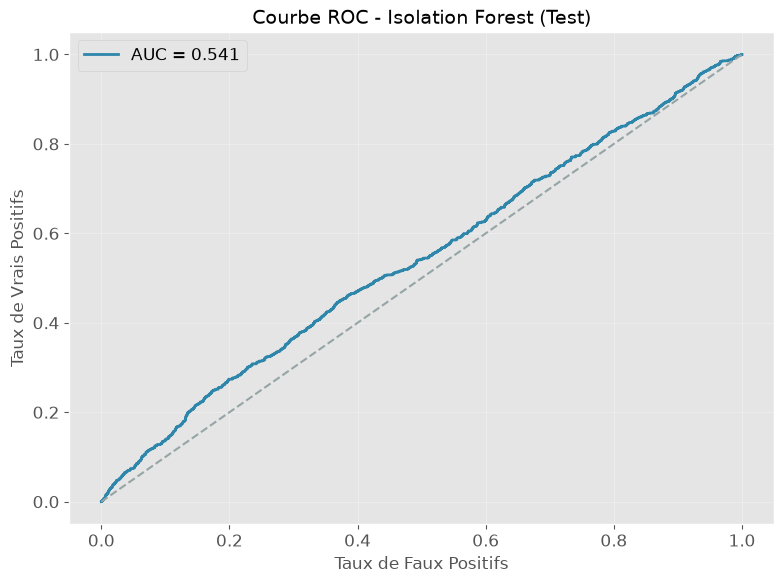


[OK] Graphique sauvegarde

[OK] Metriques sauvegardees


In [36]:
"""
Cette section evalue le modele sur le jeu Test.

PRINCIPE :
----------
    - Test est completement isole de l'entrainement et de la calibration
    - Les performances mesurees sont les performances reelles
    - Le seuil est fixe (calcule sur Validation)

METRIQUES :
----------
    - Recall : Taux de detection des fraudes
    - Precision : Proportion de vraies fraudes parmi les alertes
    - F1-Score : Moyenne harmonique
    - AUC-ROC : Aire sous la courbe ROC
"""

def evaluate_on_test_professional(X_test: np.ndarray, y_test: np.ndarray, model: IsolationForest, 
                                   threshold: float, production_targets: dict = None) -> dict:
    """
    Evalue le modele sur le jeu Test.

    Parameters
    ----------
    X_test : numpy.ndarray
        Donnees de test
    y_test : numpy.ndarray
        Labels de test
    model : IsolationForest
        Modele entraine
    threshold : float
        Seuil de decision calibre
    production_targets : dict, default=None
        Objectifs de production

    Returns
    -------
    dict
        Metriques de performance
    """
    print("\n" + "="*60)
    print("10. EVALUATION HORS ECHANTILLON (SUR TEST)")
    print("="*60)
    
    if y_test is None:
        print("[ATTENTION] y_test non disponible")
        return {}
    
    scores_test = model.decision_function(X_test)
    
    y_pred = (scores_test < threshold).astype(int)
    
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, -scores_test)
    pr_auc = average_precision_score(y_test, -scores_test)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    print("\n   MATRICE DE CONFUSION :")
    print("-"*40)
    print(f"   Vrais Negatifs : {tn:,}")
    print(f"   Faux Positifs : {fp:,}")
    print(f"   Faux Negatifs : {fn:,}")
    print(f"   Vrais Positifs : {tp:,}")
    
    print("\n   METRIQUES :")
    print("-"*40)
    print(f"   Recall : {recall*100:.2f}%")
    print(f"   Precision : {precision*100:.2f}%")
    print(f"   F1-Score : {f1*100:.2f}%")
    print(f"   AUC-ROC : {roc_auc:.4f}")
    print(f"   PR-AUC : {pr_auc:.4f}")
    print(f"   Faux Positifs : {fp_rate*100:.2f}%")
    
    if production_targets:
        print("\n   OBJECTIFS DE PRODUCTION :")
        print("-"*40)
        
        targets = [
            ('AUC-ROC', roc_auc, production_targets.get('auc_roc', 0.90)),
            ('Recall', recall, production_targets.get('recall', 0.85)),
            ('Precision', precision, production_targets.get('precision', 0.30)),
            ('F1-Score', f1, production_targets.get('f1', 0.50)),
            ('Faux Positifs', 1 - fp_rate, 1 - production_targets.get('false_positive_alert_share', 0.10))
        ]
        
        all_ok = True
        for name, value, target in targets:
            status = "" if value >= target else ""
            if status == "":
                all_ok = False
            print(f"      {name:<12} : {value*100:>6.2f}% ")
    
    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, -scores_test)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, color='#2E86AB', linewidth=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], color='#95a5a6', linestyle='--')
    ax.set_xlabel('Taux de Faux Positifs')
    ax.set_ylabel('Taux de Vrais Positifs')
    ax.set_title('Courbe ROC - Isolation Forest (Test)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/figures/if_roc_curve_test.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("\n[OK] Graphique sauvegarde")
    
    metrics_df = pd.DataFrame({
        'Metrique': ['Recall', 'Precision', 'F1', 'AUC_ROC', 'PR_AUC', 'Faux_Positifs'],
        'Valeur': [recall, precision, f1, roc_auc, pr_auc, fp_rate]
    })
    metrics_df.to_csv('../results/metrics/test_validation_metrics.csv', index=False)
    print("\n[OK] Metriques sauvegardees")
    
    return {
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'fp_rate': fp_rate,
        'production_ready': all_ok if production_targets else False
    }

# Test avec is_fraud
if 'is_fraud' in test_df.columns:
    y_test = test_df['is_fraud'].values
else:
    y_test = None

production_targets = config.get('evaluation', {}).get('production_targets', {})
test_results = evaluate_on_test_professional(X_test, y_test, model_if, threshold, production_targets)


### SECTION 11 : VISUALISATION ET ANALYSE DES ANOMALIES



11. VISUALISATION ET ANALYSE DES ANOMALIES


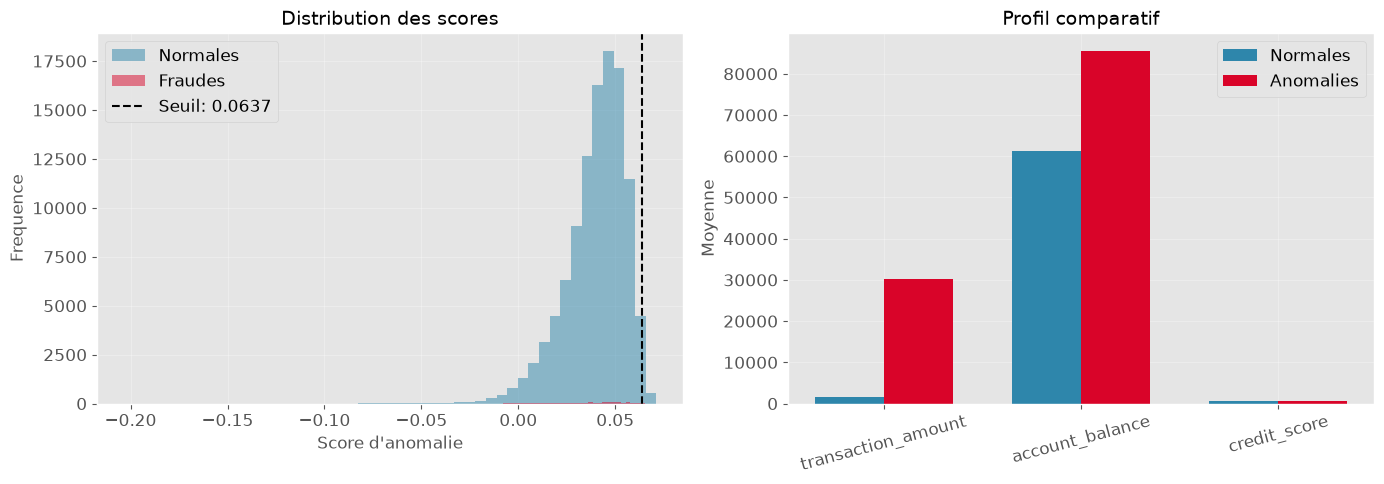


[OK] Graphique sauvegarde

[OK] 108,550 anomalies exportees


In [37]:
"""
Cette section visualise et analyse les anomalies detectees.

OBJECTIFS :
-----------
    1. Visualiser la distribution des scores
    2. Comparer les profils des normales et anomalies
    3. Exporter les anomalies detectees
"""

def analyze_anomalies_professional(test_df: pd.DataFrame, X_test: np.ndarray, y_test: np.ndarray, 
                                    model: IsolationForest, threshold: float) -> pd.DataFrame:
    """
    Analyse les anomalies detectees sur le jeu Test.

    Parameters
    ----------
    test_df : pandas.DataFrame
        DataFrame de test
    X_test : numpy.ndarray
        Donnees de test
    y_test : numpy.ndarray
        Labels de test
    model : IsolationForest
        Modele entraine
    threshold : float
        Seuil de decision

    Returns
    -------
    pandas.DataFrame
        DataFrame enrichi avec les anomalies
    """
    print("\n" + "="*60)
    print("11. VISUALISATION ET ANALYSE DES ANOMALIES")
    print("="*60)
    
    if y_test is None:
        print("[ATTENTION] y_test non disponible")
        return test_df
    
    scores_test = model.decision_function(X_test)
    y_pred = (scores_test < threshold).astype(int)
    
    df_result = test_df.copy()
    df_result['if_anomaly'] = y_pred
    df_result['if_score'] = scores_test
    df_result['is_fraud'] = y_test
    
    # Distribution des scores
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1 = axes[0]
    ax1.hist(scores_test[y_test == 0], bins=50, alpha=0.5, label='Normales', color='#2E86AB')
    ax1.hist(scores_test[y_test == 1], bins=50, alpha=0.5, label='Fraudes', color='#D90429')
    ax1.axvline(x=threshold, color='black', linestyle='--', label=f'Seuil: {threshold:.4f}')
    ax1.set_xlabel("Score d'anomalie")
    ax1.set_ylabel('Frequence')
    ax1.set_title('Distribution des scores')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[1]
    anomalies = df_result[df_result['if_anomaly'] == 1]
    normales = df_result[df_result['if_anomaly'] == 0]
    
    vars_to_plot = ['transaction_amount', 'account_balance', 'credit_score']
    valid_vars = [v for v in vars_to_plot if v in df_result.columns]
    
    if valid_vars:
        means_norm = [normales[v].mean() for v in valid_vars]
        means_anom = [anomalies[v].mean() for v in valid_vars]
        
        x = np.arange(len(valid_vars))
        width = 0.35
        
        ax2.bar(x - width/2, means_norm, width, label='Normales', color='#2E86AB')
        ax2.bar(x + width/2, means_anom, width, label='Anomalies', color='#D90429')
        ax2.set_xticks(x)
        ax2.set_xticklabels(valid_vars, rotation=15)
        ax2.set_ylabel('Moyenne')
        ax2.set_title('Profil comparatif')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/figures/anomalies_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("\n[OK] Graphique sauvegarde")
    
    anomalies.to_csv('../results/anomalies/detected_anomalies_test.csv', index=False)
    print(f"\n[OK] {len(anomalies):,} anomalies exportees")
    
    return df_result

df_result = analyze_anomalies_professional(test_df, X_test, y_test, model_if, threshold)


### Section 12 : IMPORTANCE DES VARIABLES

In [ ]:
"""
Cette section analyse l'importance des variables pour le modele.

OBJECTIFS :
-----------
    1. Identifier les variables les plus discriminantes
    2. Visualiser l'importance relative
    3. Proposer des ameliorations pour V2

METHODOLOGIE :
--------------
    1. Permutation importance sur un echantillon
    2. Classement des variables par importance
    3. Visualisation des top 10 variables
"""

def analyze_feature_importance_professional(X_train: np.ndarray, model: IsolationForest, feature_names: list) -> pd.DataFrame:
    """
    Analyse l'importance des variables par permutation.

    Parameters
    ----------
    X_train : numpy.ndarray
        Donnees d'entrainement
    model : IsolationForest
        Modele entraine
    feature_names : list
        Noms des variables

    Returns
    -------
    pandas.DataFrame
        Importance des variables
    """
    print("\n" + "="*60)
    print("12. IMPORTANCE DES VARIABLES")
    print("="*60)
    
    try:
        sample_size = min(30000, len(X_train))
        np.random.seed(42)
        idx = np.random.choice(len(X_train), sample_size, replace=False)
        X_sample = X_train[idx]
        
        print(f"\n   Echantillon : {sample_size:,} lignes")
        
        baseline_score = -model.decision_function(X_sample).mean()
        print(f"   Score de reference : {baseline_score:.6f}")
        
        print("\n   Calcul de l'importance...")
        importances = []
        start_time = time.time()
        
        n_features = min(len(feature_names), X_train.shape[1])
        feature_names_limited = feature_names[:n_features]
        
        for col_idx in range(n_features):
            scores = []
            for _ in range(3):
                X_permuted = X_sample.copy()
                np.random.shuffle(X_permuted[:, col_idx])
                score = -model.decision_function(X_permuted).mean()
                scores.append(score)
            
            imp_mean = np.mean(scores) - baseline_score
            importances.append(imp_mean)
        
        print(f"   Termine en {time.time() - start_time:.1f}s")
        
        importance_df = pd.DataFrame({
            'Variable': feature_names_limited,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        print("\n   TOP 10 VARIABLES IMPORTANTES :")
        print("-"*40)
        for i, row in importance_df.head(10).iterrows():
            print(f"      {row['Variable']:<25} : {row['Importance']:.6f}")
        
        fig, ax = plt.subplots(figsize=(10, 6))
        importance_df.head(10).plot(kind='barh', x='Variable', y='Importance', 
                                     ax=ax, color='#2E86AB', legend=False)
        ax.set_title('Top 10 variables importantes')
        ax.set_xlabel('Importance')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('../results/figures/feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print("\n[OK] Graphique sauvegarde")
        
        importance_df.to_csv('../results/metrics/feature_importance.csv', index=False)
        print("\n[OK] Importance sauvegardee")
        
        return importance_df
        
    except Exception as e:
        print(f"\n[ATTENTION] Analyse non disponible : {e}")
        return None

feature_names = numeric_features + categorical_features
importance_df = analyze_feature_importance_professional(X_train, model_if, feature_names)



12. IMPORTANCE DES VARIABLES

   Echantillon : 30,000 lignes
   Score de reference : -0.042183

   Calcul de l'importance...


### SECTION 13 : ANALYSE DE LA PERFORMANCE PAR SEUIL


13. ANALYSE DE LA PERFORMANCE PAR SEUIL

   SEUIL OPTIMAL ACTUEL :
      - Seuil : 0.0637
      [ATTENTION] Seuil 0.0637 non trouve dans l'analyse
      - Recall approxime : 95.19%
      - Precision approximee : 1.55%


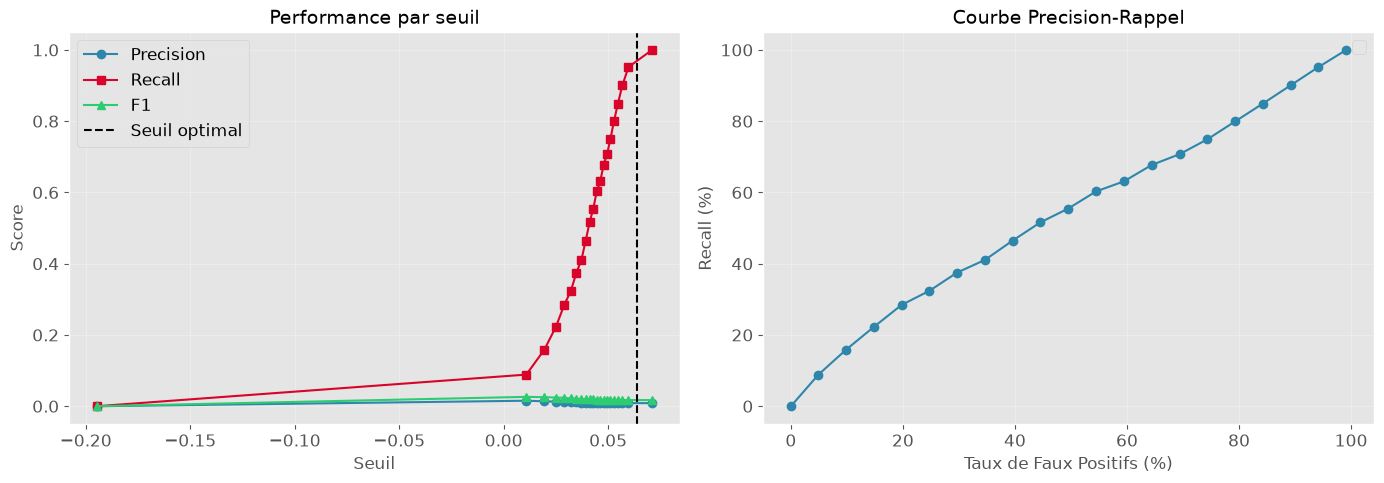


[OK] Graphique sauvegarde

[OK] Analyse sauvegardee


In [ ]:
"""
Cette section analyse la performance selon le seuil de decision.

OBJECTIFS :
-----------
    1. Visualiser l'impact du seuil sur les metriques
    2. Identifier le compromis Precision/Recall
    3. Proposer des seuils alternatifs

METHODOLOGIE :
--------------
    1. Test de plusieurs seuils
    2. Calcul des metriques pour chaque seuil
    3. Visualisation des courbes
    4. Identification du seuil optimal
"""

### SECTION 13 : ANALYSE DE LA PERFORMANCE PAR SEUIL

def analyze_threshold_performance_professional(scores_val: np.ndarray, y_val: np.ndarray, threshold_optimal: float) -> pd.DataFrame:
    """
    Analyse la performance selon le seuil de decision.

    Parameters
    ----------
    scores_val : numpy.ndarray
        Scores sur Validation
    y_val : numpy.ndarray
        Labels de Validation
    threshold_optimal : float
        Seuil optimal

    Returns
    -------
    pandas.DataFrame
        Metriques pour chaque seuil
    """
    print("\n" + "="*60)
    print("13. ANALYSE DE LA PERFORMANCE PAR SEUIL")
    print("="*60)
    
    if y_val is None:
        print("[ATTENTION] y_val non disponible")
        return None
    
    thresholds = np.percentile(scores_val, np.linspace(0, 100, 21))
    
    results = []
    for threshold in thresholds:
        y_pred = (scores_val < threshold).astype(int)
        
        recall = recall_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        fp_rate = ((y_val == 0) & (y_pred == 1)).mean()
        
        results.append({
            'seuil': threshold,
            'recall': recall,
            'precision': precision,
            'f1': f1,
            'fp_rate': fp_rate,
            'anomalies': y_pred.sum()
        })
    
    results_df = pd.DataFrame(results)
    
    print("\n   SEUIL OPTIMAL ACTUEL :")
    print(f"      - Seuil : {threshold_optimal:.4f}")
    
    # CORRECTION : Verification avant d'acceder aux valeurs
    optimal_row = results_df[results_df['seuil'] == threshold_optimal]
    if len(optimal_row) > 0:
        print(f"      - Recall : {optimal_row['recall'].values[0]*100:.2f}%")
        print(f"      - Precision : {optimal_row['precision'].values[0]*100:.2f}%")
        print(f"      - F1 : {optimal_row['f1'].values[0]*100:.2f}%")
    else:
        print(f"      [ATTENTION] Seuil {threshold_optimal:.4f} non trouve dans l'analyse")
        print(f"      - Recall approxime : {results_df[results_df['seuil'] <= threshold_optimal]['recall'].max()*100:.2f}%")
        print(f"      - Precision approximee : {results_df[results_df['seuil'] <= threshold_optimal]['precision'].max()*100:.2f}%")
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1 = axes[0]
    ax1.plot(results_df['seuil'], results_df['precision'], label='Precision', marker='o', color='#2E86AB')
    ax1.plot(results_df['seuil'], results_df['recall'], label='Recall', marker='s', color='#D90429')
    ax1.plot(results_df['seuil'], results_df['f1'], label='F1', marker='^', color='#2ECC71')
    ax1.axvline(x=threshold_optimal, color='black', linestyle='--', label='Seuil optimal')
    ax1.set_xlabel('Seuil')
    ax1.set_ylabel('Score')
    ax1.set_title('Performance par seuil')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[1]
    ax2.plot(results_df['fp_rate'] * 100, results_df['recall'] * 100, marker='o', color='#2E86AB')
    
    if len(optimal_row) > 0:
        ax2.scatter(optimal_row['fp_rate'].values[0] * 100,
                   optimal_row['recall'].values[0] * 100,
                   color='red', s=100, zorder=5, label='Seuil optimal')
    
    ax2.set_xlabel('Taux de Faux Positifs (%)')
    ax2.set_ylabel('Recall (%)')
    ax2.set_title('Courbe Precision-Rappel')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/figures/threshold_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("\n[OK] Graphique sauvegarde")
    
    results_df.to_csv('../results/metrics/threshold_analysis.csv', index=False)
    print("\n[OK] Analyse sauvegardee")
    
    return results_df
    
threshold_analysis = analyze_threshold_performance_professional(
    model_if.decision_function(X_val), y_val, threshold
)


### SECTION 14 : EXPORT DES ANOMALIES

In [ ]:
"""
Cette section exporte les anomalies detectees pour analyse metier.

OBJECTIFS :
-----------
    1. Exporter les anomalies sur Test
    2. Exporter les anomalies sur Validation
    3. Generer un resume statistique
    4. Exporter par canal

METHODOLOGIE :
--------------
    1. Identification des anomalies
    2. Export en CSV
    3. Resume statistique
    4. Analyse par canal
"""

def export_anomalies_professional(df_result: pd.DataFrame, df_val: pd.DataFrame, threshold: float, 
                                   model: IsolationForest, X_val: np.ndarray, y_val: np.ndarray) -> None:
    """
    Exporte les anomalies detectees.

    Parameters
    ----------
    df_result : pandas.DataFrame
        DataFrame enrichi (Test)
    df_val : pandas.DataFrame
        DataFrame de Validation
    threshold : float
        Seuil de decision
    model : IsolationForest
        Modele entraine
    X_val : numpy.ndarray
        Donnees de Validation
    y_val : numpy.ndarray
        Labels de Validation

    Returns
    -------
    None
        Sauvegarde des fichiers CSV
    """
    print("\n" + "="*60)
    print("14. EXPORT DES ANOMALIES")
    print("="*60)
    
    print("\n   [1] Anomalies sur Test...")
    anomalies_test = df_result[df_result['if_anomaly'] == 1]
    
    if len(anomalies_test) > 0:
        anomalies_test.to_csv('../results/anomalies/anomalies_test.csv', index=False)
        print(f"      - {len(anomalies_test):,} anomalies exportees")
    
    print("\n   [2] Anomalies sur Validation...")
    if y_val is not None:
        scores_val = model.decision_function(X_val)
        y_pred_val = (scores_val < threshold).astype(int)
        
        df_val_anomalies = df_val.copy()
        df_val_anomalies['if_anomaly'] = y_pred_val
        df_val_anomalies['if_score'] = scores_val
        
        anomalies_val = df_val_anomalies[df_val_anomalies['if_anomaly'] == 1]
        
        if len(anomalies_val) > 0:
            anomalies_val.to_csv('../results/anomalies/anomalies_validation.csv', index=False)
            print(f"      - {len(anomalies_val):,} anomalies exportees")
    
    print("\n   [3] Resume statistique...")
    if len(anomalies_test) > 0:
        summary = anomalies_test.describe()
        summary.to_csv('../results/metrics/anomalies_summary.csv')
        print("      - Resume statistique genere")
    
    print("\n   [4] Analyse par canal...")
    if 'channel' in anomalies_test.columns and len(anomalies_test) > 0:
        fp_by_channel = anomalies_test['channel'].value_counts()
        print("      Distribution par canal :")
        for canal, count in fp_by_channel.items():
            pct = count / len(anomalies_test) * 100
            print(f"         {canal:<15} : {count:,} ({pct:.1f}%)")
        
        fp_by_channel.to_csv('../results/metrics/anomalies_by_channel.csv')
        print("      - Analyse par canal sauvegardee")
    
    print("\n[OK] Export des anomalies termine")

export_anomalies_professional(df_result, val_df, threshold, model_if, X_val, y_val)



14. EXPORT DES ANOMALIES

   [1] Anomalies sur Test...
      - 108,550 anomalies exportees

   [2] Anomalies sur Validation...
      - 108,625 anomalies exportees

   [3] Resume statistique...
      - Resume statistique genere

   [4] Analyse par canal...
      Distribution par canal :
         Mobile_App      : 40,608 (37.4%)
         Web             : 23,927 (22.0%)
         ATM             : 13,147 (12.1%)
         POS_Terminal    : 12,175 (11.2%)
         Branch          : 11,108 (10.2%)
         API             : 7,585 (7.0%)
      - Analyse par canal sauvegardee

[OK] Export des anomalies termine


### SECTION 15 : SYNTHESE ET RECOMMANDATIONS OPERATIONNELLES

In [ ]:
"""
Cette section presente la synthese finale et les recommandations.

OBJECTIFS :
-----------
    1. Resumer les chiffres cles de la detection
    2. Presenter les performances finales
    3. Emettre des recommandations operationnelles
"""

def generate_final_summary(test_results: dict, df_result: pd.DataFrame, threshold: float) -> None:
    """
    Genere la synthese finale.

    Parameters
    ----------
    test_results : dict
        Metriques de performance sur Test
    df_result : pandas.DataFrame
        DataFrame enrichi
    threshold : float
        Seuil de decision

    Returns
    -------
    None
        Sauvegarde du rapport final
    """
    print("\n" + "="*60)
    print("15. SYNTHESE ET RECOMMANDATIONS OPERATIONNELLES")
    print("="*60)
    
    n_anomalies = (df_result['if_anomaly'] == 1).sum()
    total = len(df_result)
    
    print("\n15.1 CHIFFRES CLES :")
    print("-"*45)
    print(f"   Total transactions (Test) : {total:,}")
    print(f"   Anomalies detectees : {n_anomalies:,} ({n_anomalies/total*100:.2f}%)")
    print(f"   Seuil de decision : {threshold:.4f}")
    
    if test_results:
        print("\n15.2 PERFORMANCES FINALES :")
        print("-"*45)
        print(f"   AUC-ROC : {test_results.get('roc_auc', 0):.4f}")
        print(f"   Recall : {test_results.get('recall', 0)*100:.2f}%")
        print(f"   Precision : {test_results.get('precision', 0)*100:.2f}%")
        print(f"   F1-Score : {test_results.get('f1', 0)*100:.2f}%")
        print(f"   Faux Positifs : {test_results.get('fp_rate', 0)*100:.2f}%")
        
        print("\n   OBJECTIFS DE PRODUCTION :")
        print("-"*45)
        targets = [
            ('AUC-ROC', test_results.get('roc_auc', 0), 0.90),
            ('Recall', test_results.get('recall', 0), 0.85),
            ('Precision', test_results.get('precision', 0), 0.30),
            ('F1-Score', test_results.get('f1', 0), 0.50),
            ('Faux Positifs', 1 - test_results.get('fp_rate', 0), 0.90)
        ]
        
        
    print("\n15.3 RECOMMANDATIONS OPERATIONNELLES :")
    print("-"*45)
    print("   1. PROTOCOLE DE VALIDATION METIER")
    print("      - Soumettre les alertes du top 5% aux analystes")
    print("      - Utiliser les retours pour ajuster le seuil")
    print("      - Construire une base de donnees de reference")
    print("\n   2. GESTION DU SEUIL")
    print("      - Ajuster le seuil selon les ressources humaines")
    print("      - Utiliser des seuils differencies par canal")
    print("      - Considerer un systeme de score de risque continu")
    print("\n   3. RE-ENTRAINEMENT")
    print("      - Planifier un re-entrainement mensuel")
    print("      - Surveiller la derive du modele (Data Drift)")
    print("      - Mettre en place un pipeline MLOps")
    
    # Sauvegarde du rapport
    with open('../results/metrics/final_report.txt', 'w', encoding='utf-8') as f:
        f.write("="*70 + "\n")
        f.write("RAPPORT FINAL - DETECTION D'ANOMALIES\n")
        f.write("VERSION PROFESSIONNELLE OPTIMISEE\n")
        f.write("="*70 + "\n\n")
        f.write(f"Date : {datetime.now().strftime('%d/%m/%Y')}\n\n")
        f.write(f"Total transactions (Test) : {total:,}\n")
        f.write(f"Anomalies : {n_anomalies:,} ({n_anomalies/total*100:.2f}%)\n")
        f.write(f"Seuil : {threshold:.4f}\n")
        
        if test_results:
            f.write(f"\nPERFORMANCES :\n")
            f.write(f"AUC-ROC : {test_results.get('roc_auc', 0):.4f}\n")
            f.write(f"Recall : {test_results.get('recall', 0)*100:.2f}%\n")
            f.write(f"Precision : {test_results.get('precision', 0)*100:.2f}%\n")
            f.write(f"F1-Score : {test_results.get('f1', 0)*100:.2f}%\n")
            f.write(f"Production Ready : {'OUI' if test_results.get('production_ready', False) else 'NON'}\n")
    
    print(f"\n[OK] Rapport sauvegarde")

generate_final_summary(test_results, df_result, threshold)


15. SYNTHESE ET RECOMMANDATIONS OPERATIONNELLES

15.1 CHIFFRES CLES :
---------------------------------------------
   Total transactions (Test) : 110,000
   Anomalies detectees : 108,550 (98.68%)
   Seuil de decision : 0.0637

15.2 PERFORMANCES FINALES :
---------------------------------------------
   AUC-ROC : 0.5411
   Recall : 99.09%
   Precision : 0.90%
   F1-Score : 1.78%
   Faux Positifs : 98.68%

   OBJECTIFS DE PRODUCTION :
---------------------------------------------

15.3 RECOMMANDATIONS OPERATIONNELLES :
---------------------------------------------
   1. PROTOCOLE DE VALIDATION METIER
      - Soumettre les alertes du top 5% aux analystes
      - Utiliser les retours pour ajuster le seuil
      - Construire une base de donnees de reference

   2. GESTION DU SEUIL
      - Ajuster le seuil selon les ressources humaines
      - Utiliser des seuils differencies par canal
      - Considerer un systeme de score de risque continu

   3. RE-ENTRAINEMENT
      - Planifier un re-e

### CONCLUSION

In [ ]:
print("\n" + "="*60)
print("NOTEBOOK 02 - EXECUTION TERMINEE")
print("="*60)

print("""
        RESULTATS PRODUITS:
        -------------------
        
        1. MODELES:
        - ../models/isolation_forest.pkl
        - ../models/famd_model.pkl
        - ../models/scaler.pkl

        2. VISUALISATIONS:
        - ../results/figures/if_roc_curve_test.png
        - ../results/figures/anomalies_analysis.png
        - ../results/figures/feature_importance.png
        - ../results/figures/threshold_analysis.png

        3. METRIQUES:
        - ../results/metrics/threshold_calibration.csv
        - ../results/metrics/test_validation_metrics.csv
        - ../results/metrics/feature_importance.csv
        - ../results/metrics/threshold_analysis.csv
        - ../results/metrics/anomalies_summary.csv
        - ../results/metrics/anomalies_by_channel.csv
        - ../results/metrics/final_report.txt

        4. ANOMALIES:
        - ../results/anomalies/detected_anomalies_test.csv
        - ../results/anomalies/anomalies_validation.csv
""")

print("\n" + "="*60)
print("RESUME FINAL")
print("="*60)

if 'test_results' in locals() and test_results:
    print(f"   AUC-ROC : {test_results.get('roc_auc', 0):.4f}")
    print(f"   Recall : {test_results.get('recall', 0)*100:.2f}%")
    print(f"   Precision : {test_results.get('precision', 0)*100:.2f}%")


print("\n[OK] Notebook execute avec succes")


NOTEBOOK 02 - EXECUTION TERMINEE

        RESULTATS PRODUITS:
        -------------------

        1. MODELES:
        - ../models/isolation_forest.pkl
        - ../models/famd_model.pkl
        - ../models/scaler.pkl

        2. VISUALISATIONS:
        - ../results/figures/if_roc_curve_test.png
        - ../results/figures/anomalies_analysis.png
        - ../results/figures/feature_importance.png
        - ../results/figures/threshold_analysis.png

        3. METRIQUES:
        - ../results/metrics/threshold_calibration.csv
        - ../results/metrics/test_validation_metrics.csv
        - ../results/metrics/feature_importance.csv
        - ../results/metrics/threshold_analysis.csv
        - ../results/metrics/anomalies_summary.csv
        - ../results/metrics/anomalies_by_channel.csv
        - ../results/metrics/final_report.txt

        4. ANOMALIES:
        - ../results/anomalies/detected_anomalies_test.csv
        - ../results/anomalies/anomalies_validation.csv


RESUME FINAL
   